In [39]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 300

In [40]:
# load raw prices
data = pd.read_csv('data/GLD_5yrs_historical_prices.csv',
                    parse_dates=['Date']) \
            .sort_values('Date')

dates = data[['Date']].to_numpy()
prices = data[['Close/Last']].to_numpy()
dates, prices

(array([['2021-02-01T00:00:00.000000000'],
        ['2021-02-02T00:00:00.000000000'],
        ['2021-02-03T00:00:00.000000000'],
        ...,
        ['2026-01-28T00:00:00.000000000'],
        ['2026-01-29T00:00:00.000000000'],
        ['2026-01-30T00:00:00.000000000']],
       shape=(1256, 1), dtype='datetime64[ns]'),
 array([[174.23],
        [172.11],
        [171.85],
        ...,
        [494.56],
        [495.9 ],
        [444.95]], shape=(1256, 1)))

In [41]:
# get returns and log returns
rets = (prices[1:, ] - prices[:-1, ]) / prices[:-1, ]
logrets = np.log(1 + rets)
rets, logrets

(array([[-0.01216782],
        [-0.00151066],
        [-0.0215304 ],
        ...,
        [ 0.03877337],
        [ 0.00270948],
        [-0.10274249]], shape=(1255, 1)),
 array([[-0.01224246],
        [-0.0015118 ],
        [-0.02176557],
        ...,
        [ 0.03804056],
        [ 0.00270582],
        [-0.10841238]], shape=(1255, 1)))

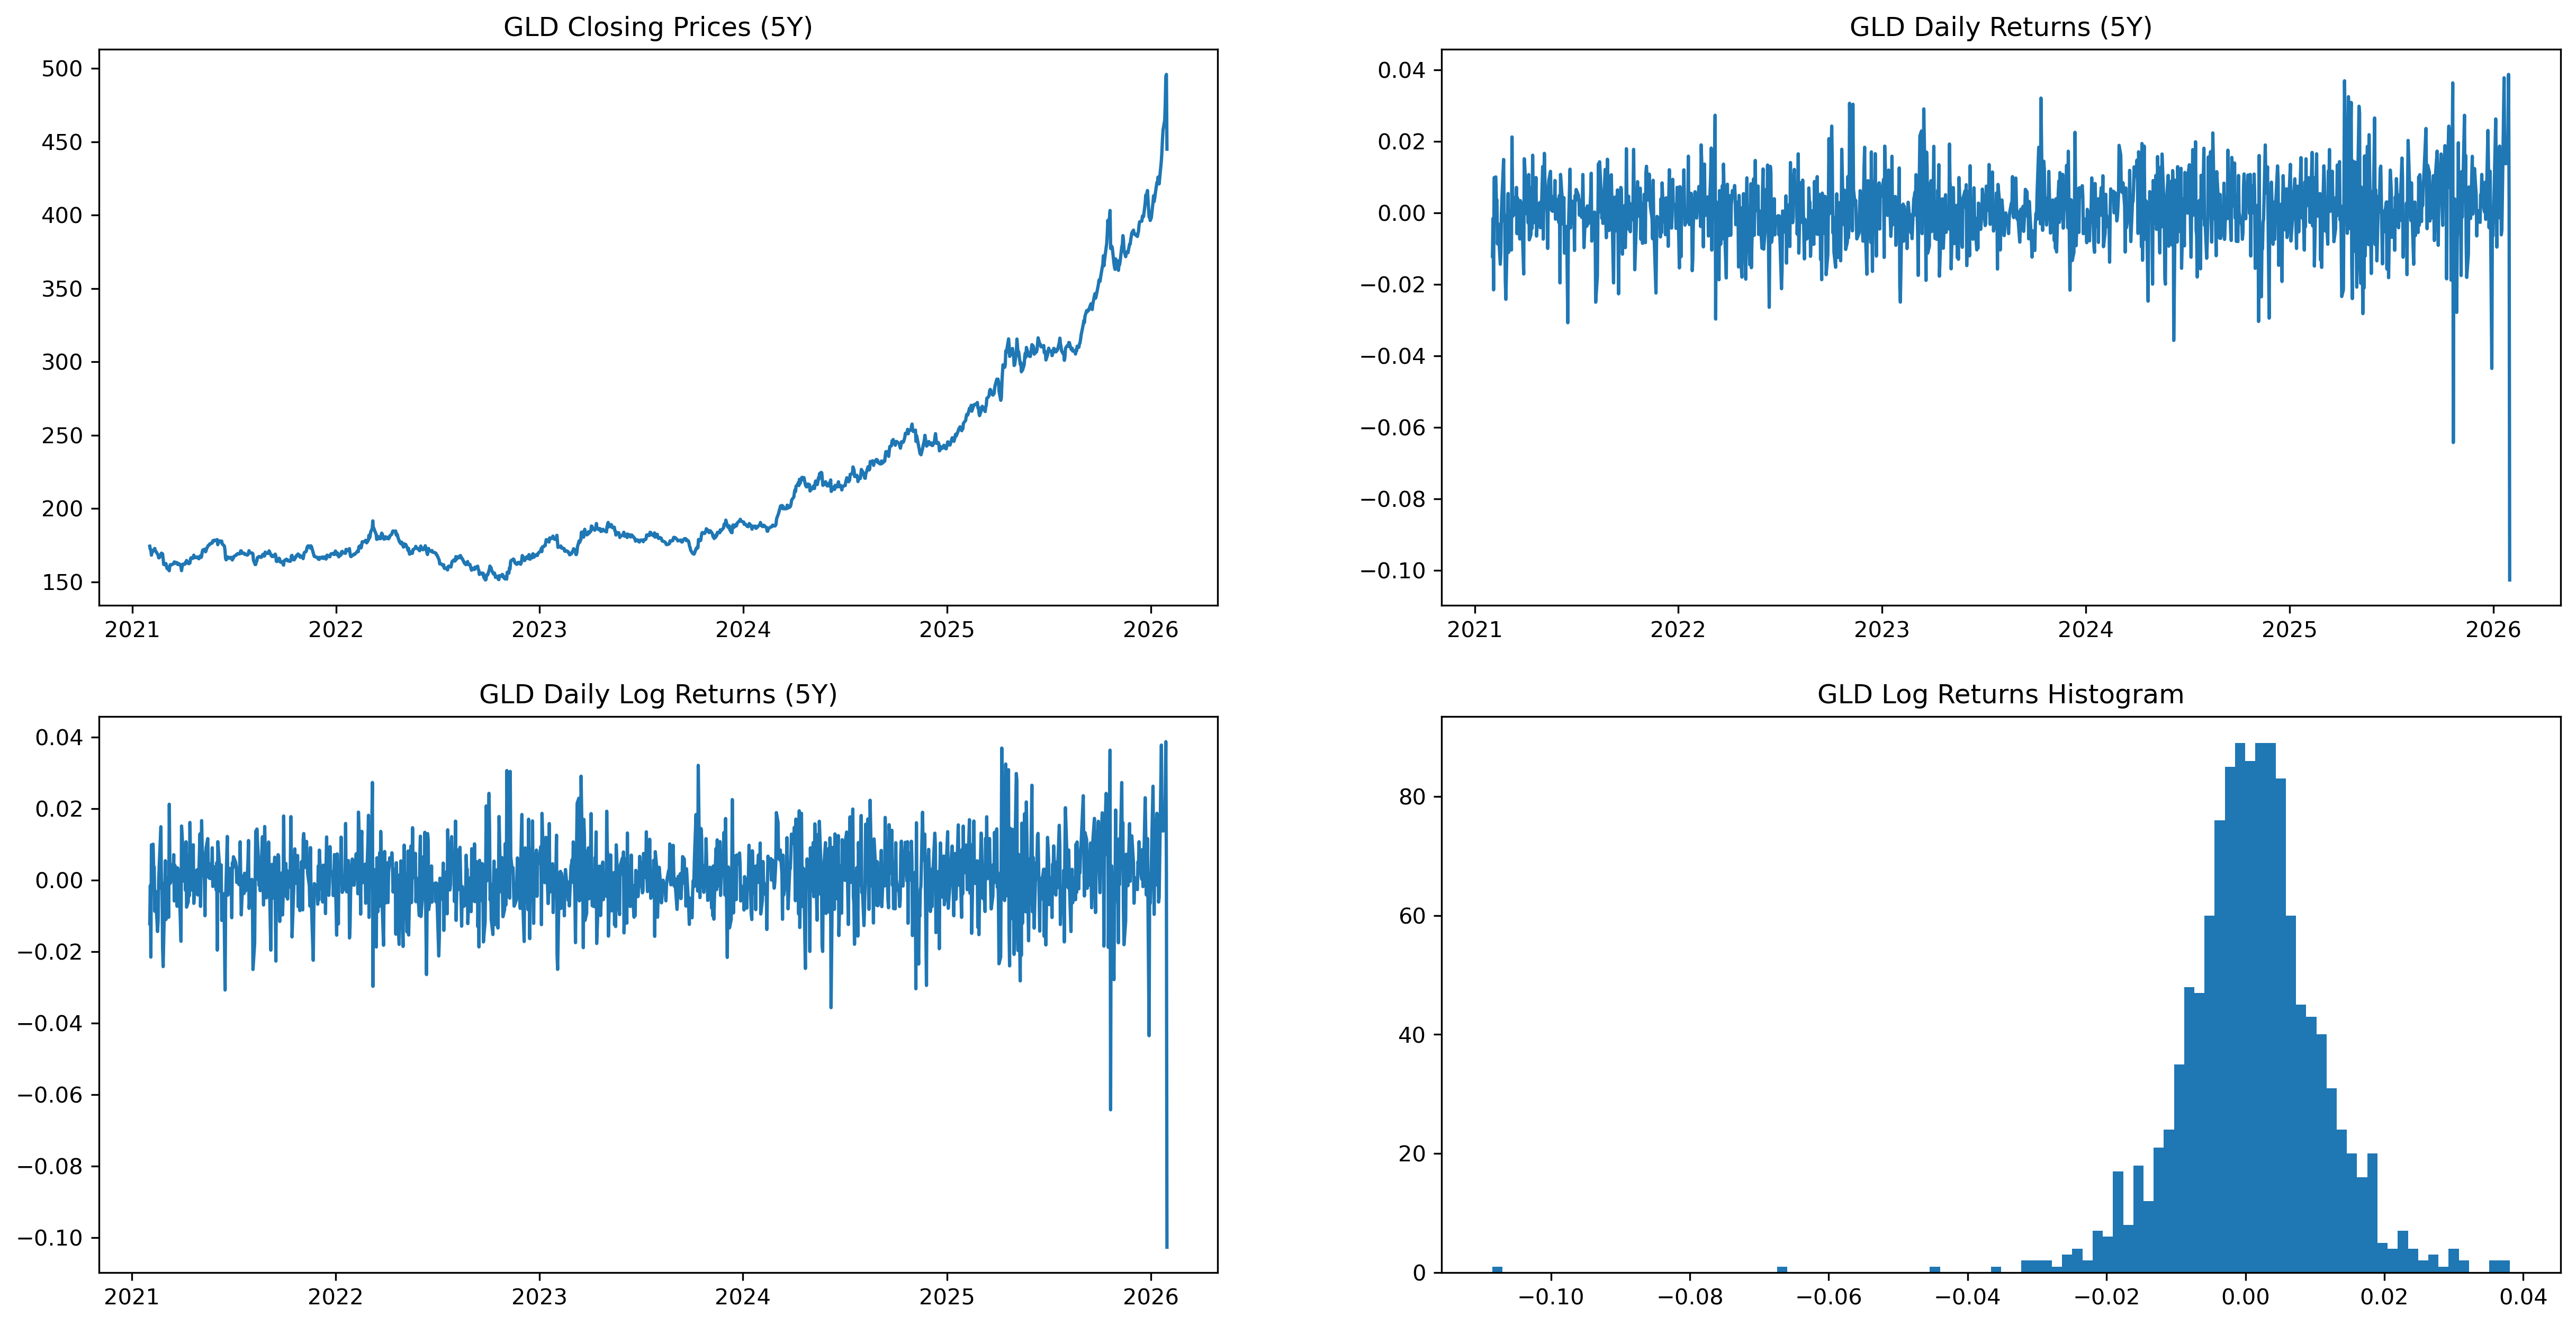

In [42]:
# plot returns
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
fig.set_size_inches(20, 10)

ax1.plot(dates, prices);
ax1.set_title('GLD Closing Prices (5Y)');

ax2.plot(dates[1:], rets);
ax2.set_title('GLD Daily Returns (5Y)');

ax3.plot(dates[1:], rets);
ax3.set_title('GLD Daily Log Returns (5Y)');

ax4.hist(logrets, bins=100);
ax4.set_title('GLD Log Returns Histogram');

In [43]:
fig.savefig('images/risk-1-GLD-returns.png', bbox_inches='tight', pad_inches=0.1)

Gaussian Fit:
mu_hat: 0.0007
sigma_hat: 0.0104 

Student's-t Fit:
df_hat: 4.7146
loc_hat: 0.0009
scale_hat: 0.0078



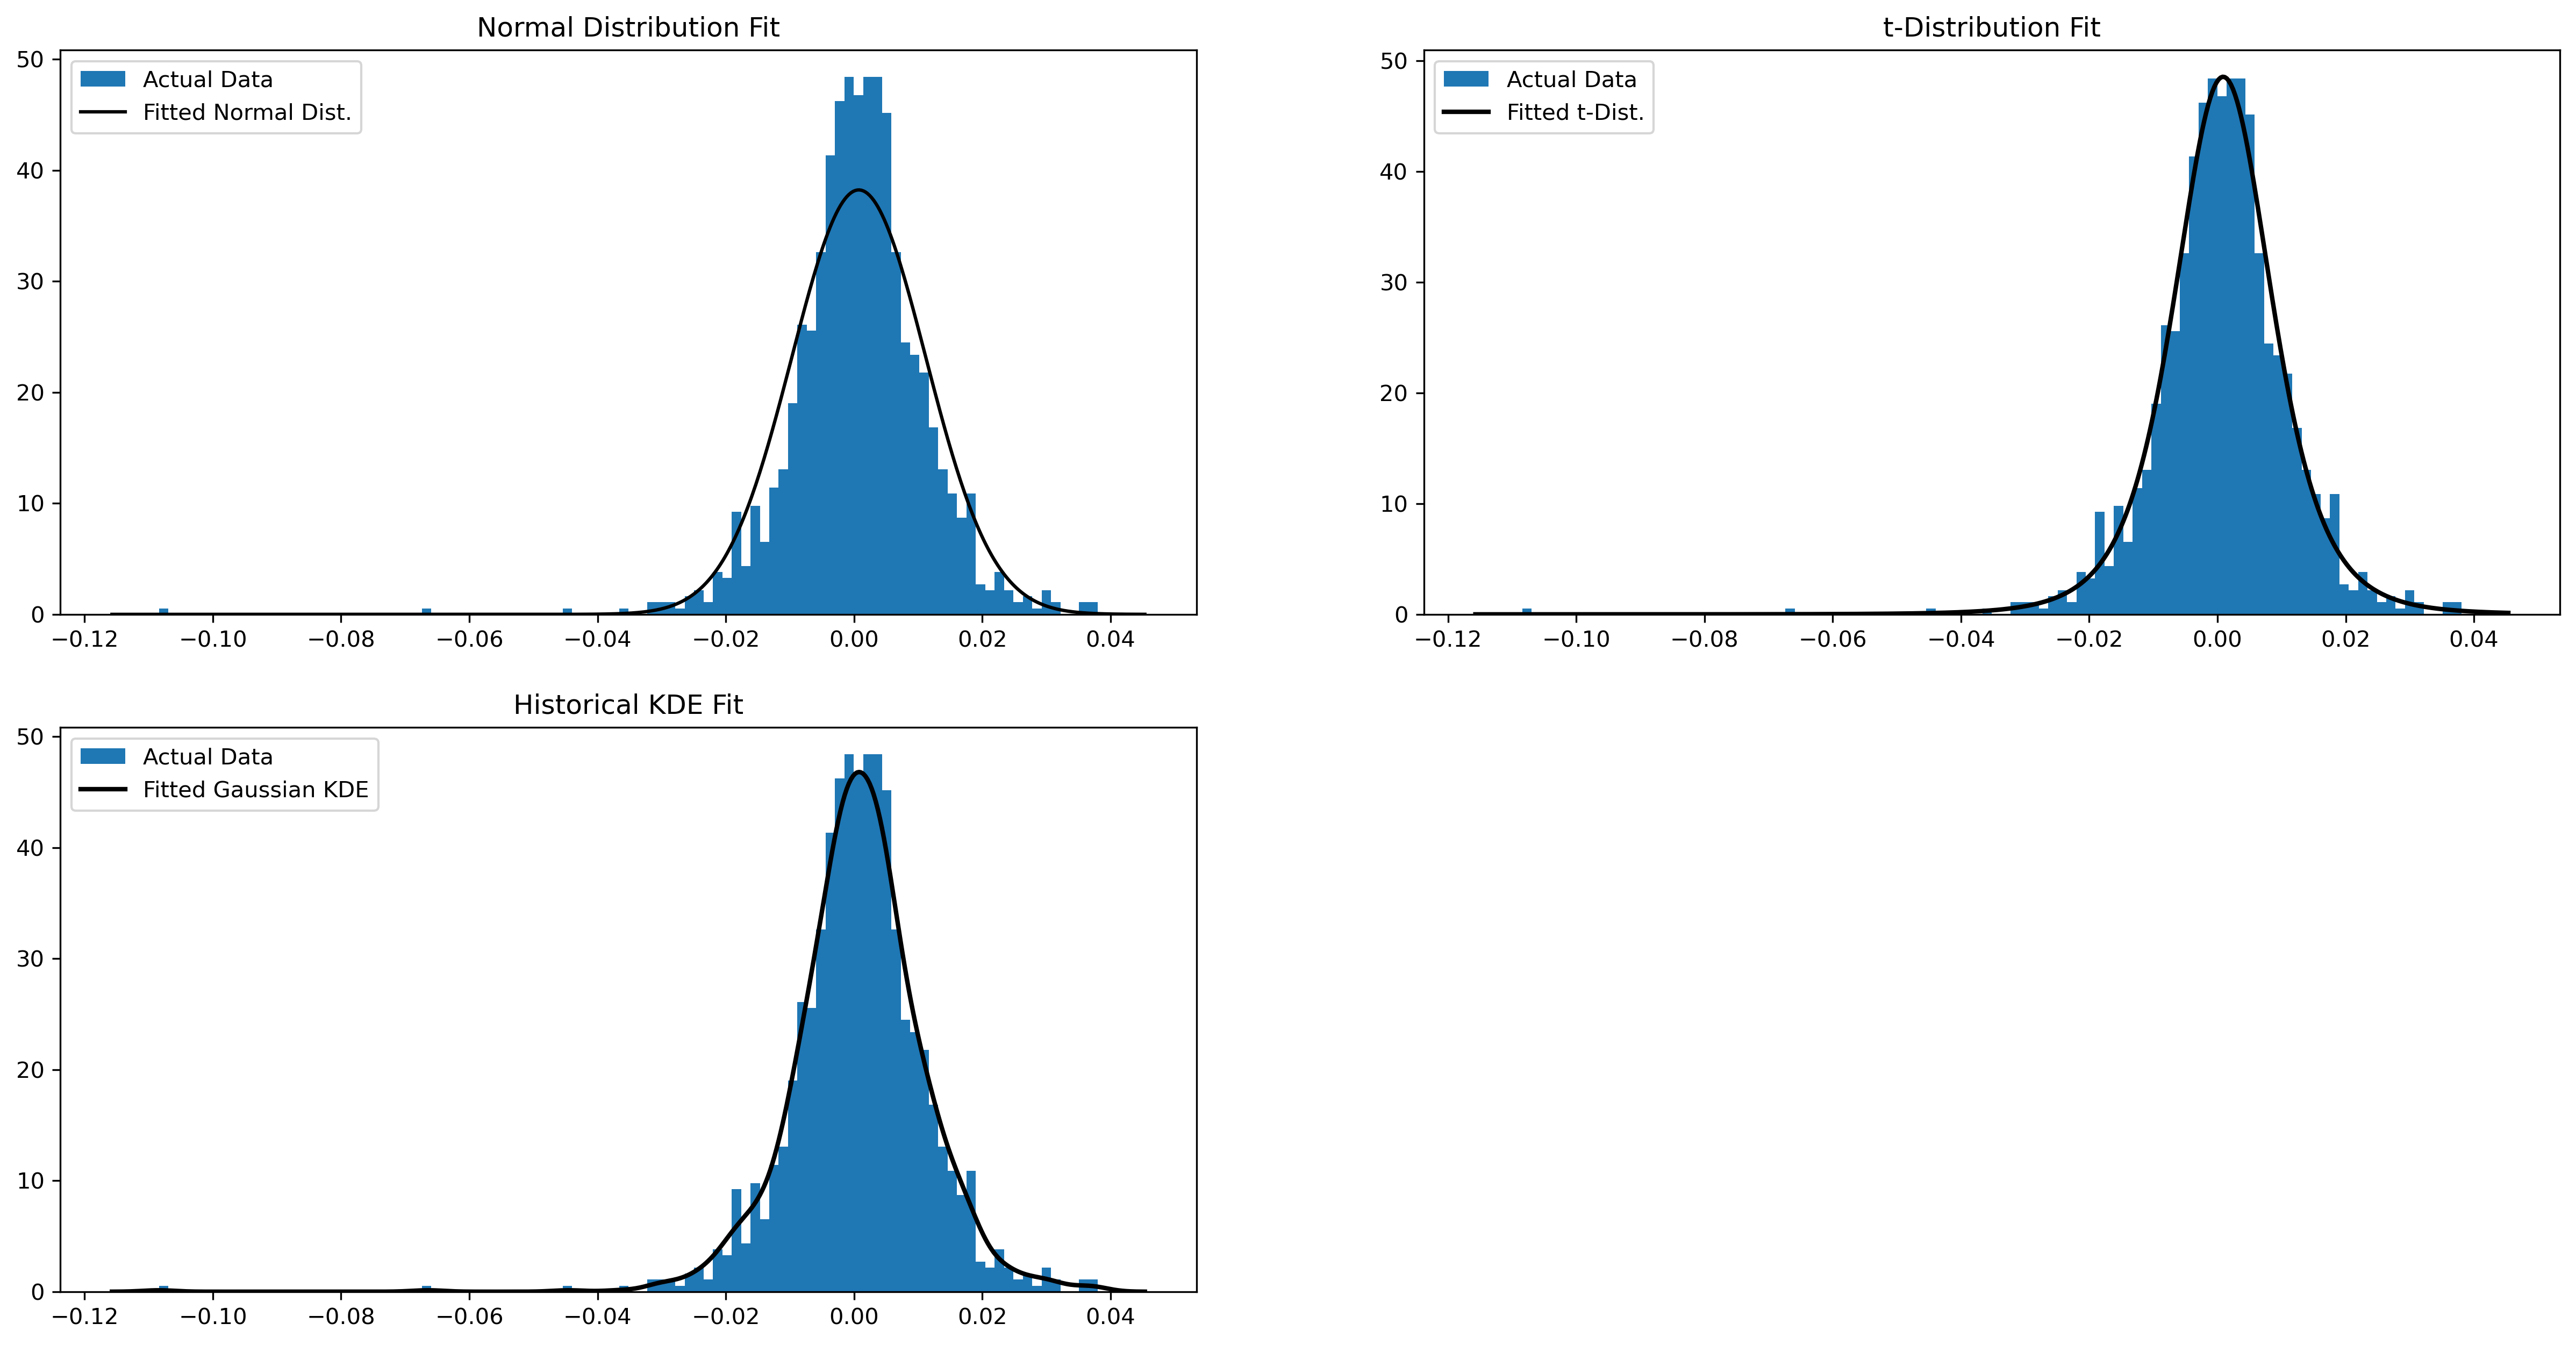

In [44]:
# fit normal, t, and kde
mu, sigma = sp.stats.norm.fit(logrets)
print('Gaussian Fit:')
print(f"mu_hat: {mu:.4f}")
print(f"sigma_hat: {sigma:.4f} \n")

df, loc, scale = sp.stats.t.fit(logrets)
print('Student\'s-t Fit:')
print(f"df_hat: {df:.4f}")
print(f"loc_hat: {loc:.4f}")
print(f"scale_hat: {scale:.4f}\n")

kde = sp.stats.gaussian_kde(logrets.T)
def kde_cdf(x):
    return kde.integrate_box_1d(-np.inf, x)
def kde_q(q):
    return sp.optimize.brentq(lambda x: kde_cdf(x) - q,
                     logrets.min(), logrets.max())

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
fig.set_size_inches(20, 10)

ax1.hist(logrets, bins=100, 
            density=True, 
                        label='Actual Data');
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 500)
pnorm = sp.stats.norm.pdf(x, mu, sigma)
ax1.plot(x, pnorm, 'k', 
            label='Fitted Normal Dist.')
ax1.set_title("Normal Distribution Fit")
ax1.legend(loc='upper left');

ax2.hist(logrets, bins=100, density=True, 
            label='Actual Data');
pt = sp.stats.t.pdf(x, df, loc, scale)
ax2.plot(x, pt, 'k', linewidth=2, 
            label='Fitted t-Dist.')
ax2.set_title("t-Distribution Fit")
ax2.legend(loc='upper left');

ax3.hist(logrets, bins=100, density=True, 
            label='Actual Data');
pkde = kde(x)
ax3.plot(x, pkde, 'k', linewidth=2, 
            label='Fitted Gaussian KDE')
ax3.set_title("Historical KDE Fit")
ax3.legend(loc='upper left');

ax4.set_visible(False);

In [45]:
fig.savefig('images/risk-2-prob-dists.png', bbox_inches='tight', pad_inches=0.1)

In [46]:
# compute VaRs at 99% confidence
alpha = 0.01

_norm_var = sp.stats.norm.ppf(q=alpha, loc=mu, scale=sigma)
norm_var = -1 * (np.exp(_norm_var) - 1)

_t_var = sp.stats.t.ppf(q=alpha, df=df, loc=loc, scale=scale)
t_var = -1 * (np.exp(_t_var) - 1)

_hist_var = kde_q(q=alpha)
hist_var = -1 * (np.exp(_hist_var) - 1)

f'{norm_var * 100:.4f}%', f'{t_var * 100:.4f}%', f'{hist_var * 100:.4f}%'

('2.3253%', '2.5676%', '2.5718%')

Normal VaR: 2.3253%, t-distribution VaR: 2.5676%, Historical VaR: 2.5718%


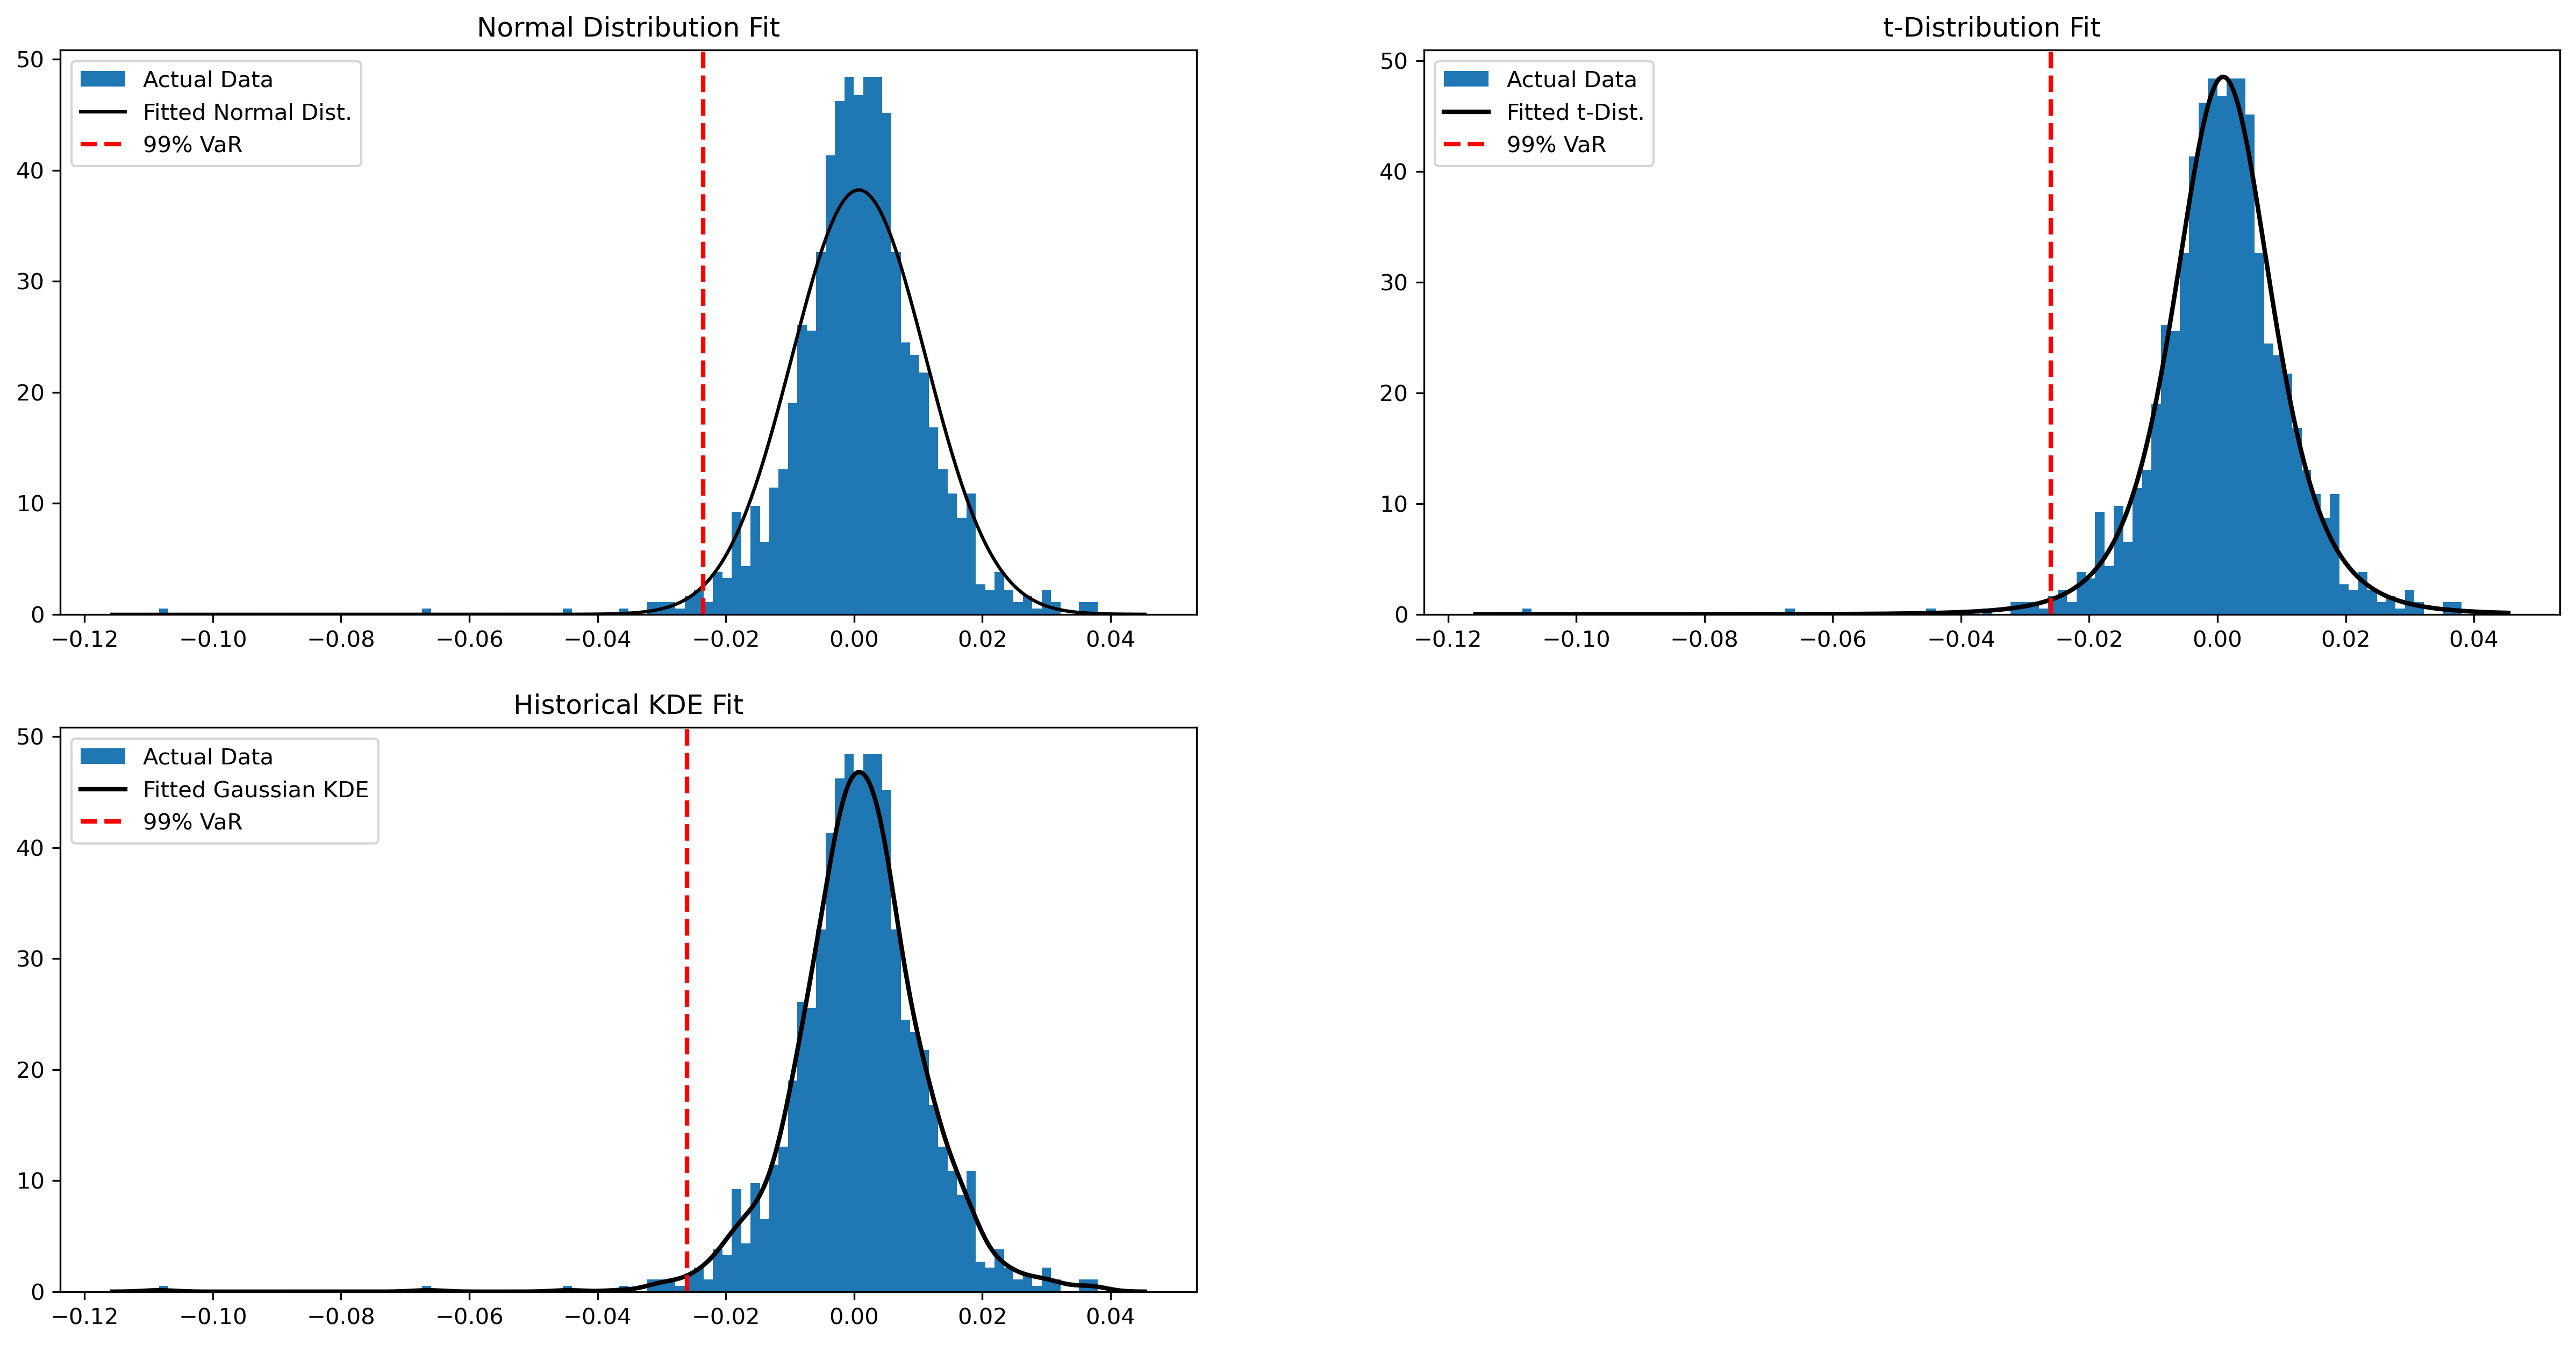

In [47]:
print(f'''Normal VaR: {norm_var * 100:.4f}%, t-distribution VaR: {t_var * 100:.4f}%, Historical VaR: {hist_var * 100:.4f}%''')

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
fig.set_size_inches(20, 10)

ax1.hist(logrets, bins=100, 
            density=True, label='Actual Data');
ax1.plot(x, pnorm, 'k', label='Fitted Normal Dist.')
ax1.set_title("Normal Distribution Fit")
ax1.axvline(x=_norm_var, color='r', linestyle='--', linewidth=2, label='99% VaR');
ax1.legend(loc='upper left');

ax2.hist(logrets, bins=100, density=True, label='Actual Data');
ax2.plot(x, pt, 'k', linewidth=2, label='Fitted t-Dist.')
ax2.set_title("t-Distribution Fit")
ax2.axvline(x=_t_var, color='r', linestyle='--', linewidth=2, label='99% VaR');
ax2.legend(loc='upper left');

ax3.hist(logrets, bins=100, density=True, label='Actual Data');
ax3.plot(x, pkde, 'k', linewidth=2, label='Fitted Gaussian KDE')
ax3.set_title("Historical KDE Fit")
ax3.axvline(x=_hist_var, color='r', linestyle='--', linewidth=2, label='99% VaR');
ax3.legend(loc='upper left');

ax4.set_visible(False);

In [49]:
fig.savefig('images/risk-3-vars.png', bbox_inches='tight', pad_inches=0.1)

In [52]:
# backtest VaRs
n = len(logrets)
_vars = [_norm_var, _t_var, _hist_var]
reject_min = sp.stats.chi2.ppf(q=1 - alpha, df=1) 

print(f'Reject when lr >= {reject_min:.4f}')

for _var in _vars:
    breaches = (sum(logrets <= _var))[0]
    p0 = alpha
    p = breaches / n
    y = breaches

    num = (p0**y) * (1 - p0)**(n - y)
    den = (p**y) * (1 - p)**(n - y)

    lr = num / den

    print((-2 * np.log(lr), -2 * np.log(lr) >= reject_min))

Reject when lr >= 6.6349
(np.float64(2.107380750041238), np.False_)
(np.float64(0.20177423466662517), np.False_)
(np.float64(0.20177423466662517), np.False_)


In [53]:
# we fail to reject the computed VaRs under any method